### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import tensorflow as tf

In [48]:
from tensorflow.keras import layers

In [30]:
from sklearn.preprocessing import MinMaxScaler

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [4]:
data = pd.read_csv('./data/all_stocks_5yr.csv')

In [7]:
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [11]:
data['date'] = pd.to_datetime(data['date'])

In [12]:
data.shape

(619040, 7)

In [13]:
data.describe()

,date,open,high,low,close,volume
count,619040,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,2015-08-18 00:48:23.494443264,83.023334,83.778311,82.256096,83.043763,4.321823e+06
min,2013-02-08 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2014-05-20 00:00:00,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,2015-08-21 00:00:00,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,2016-11-15 00:00:00,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2018-02-07 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,97.378769,98.207519,96.507421,97.389748,8.693610e+06


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


### Step 3: Exploratory Data Analysis

In [16]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

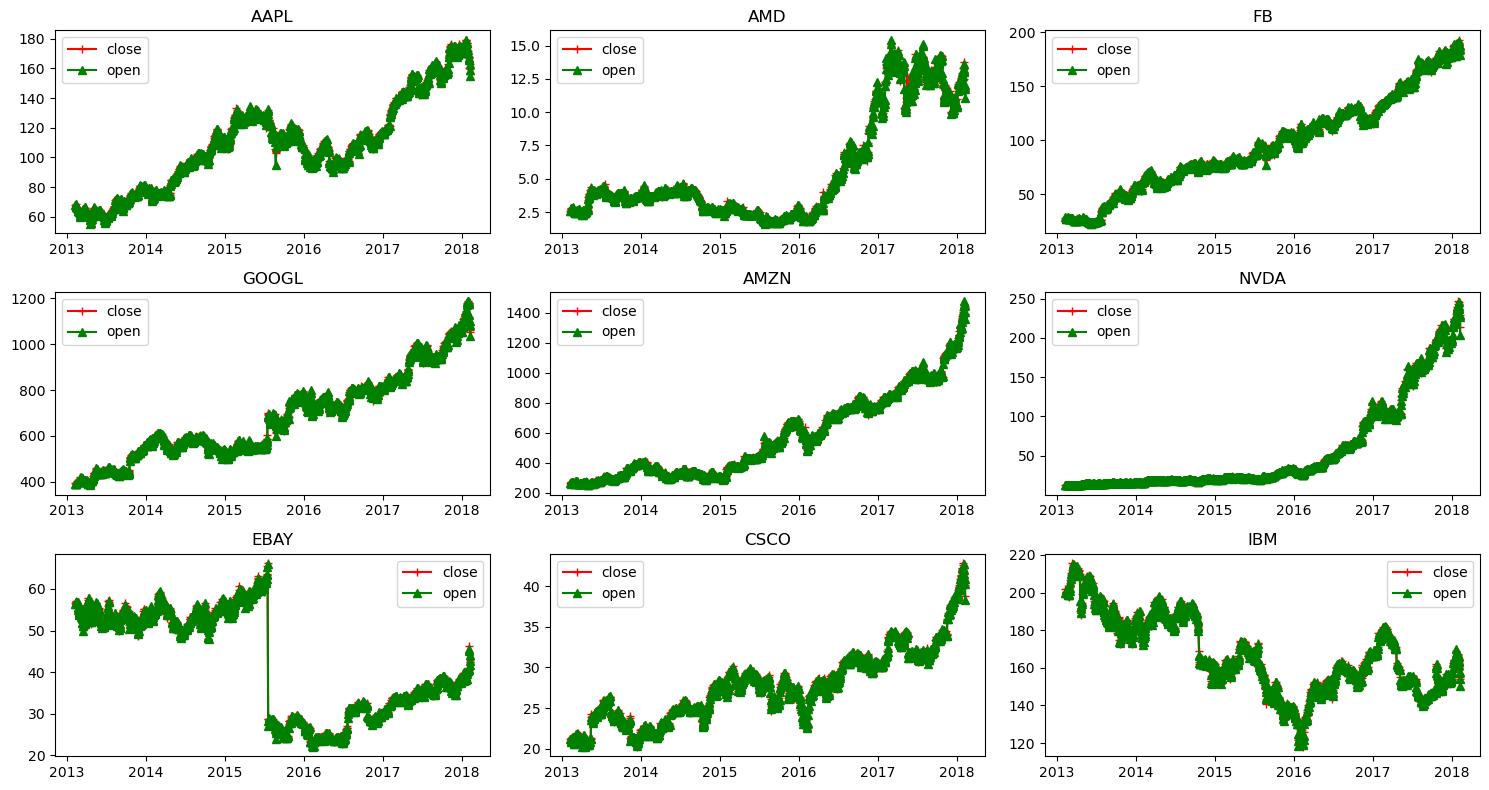

In [18]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c='r', label='close', marker='+')
    plt.plot(c['date'], c['open'], c='g', label='open', marker='^')
    plt.title(company)
    plt.legend()
    plt.tight_layout()

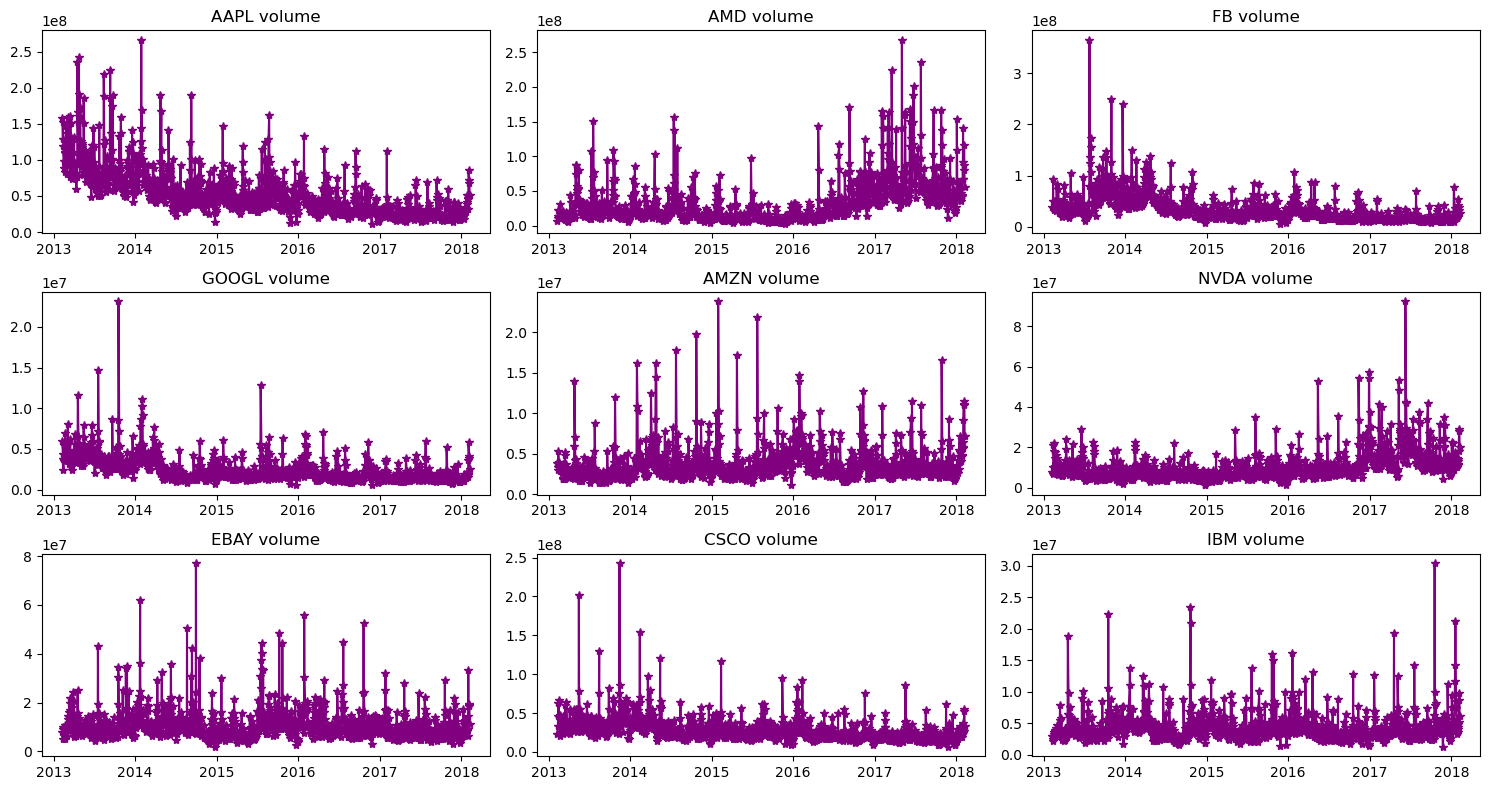

In [20]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='purple', marker='*')
    plt.title(f'{company} volume')
    plt.tight_layout()

In [21]:
apple = data[data['Name'] == 'AAPL']

In [22]:
prediction_range = apple.loc[(apple['date'] > datetime(2013, 1, 1)) & (apple['date'] < datetime(2018, 1, 1))]

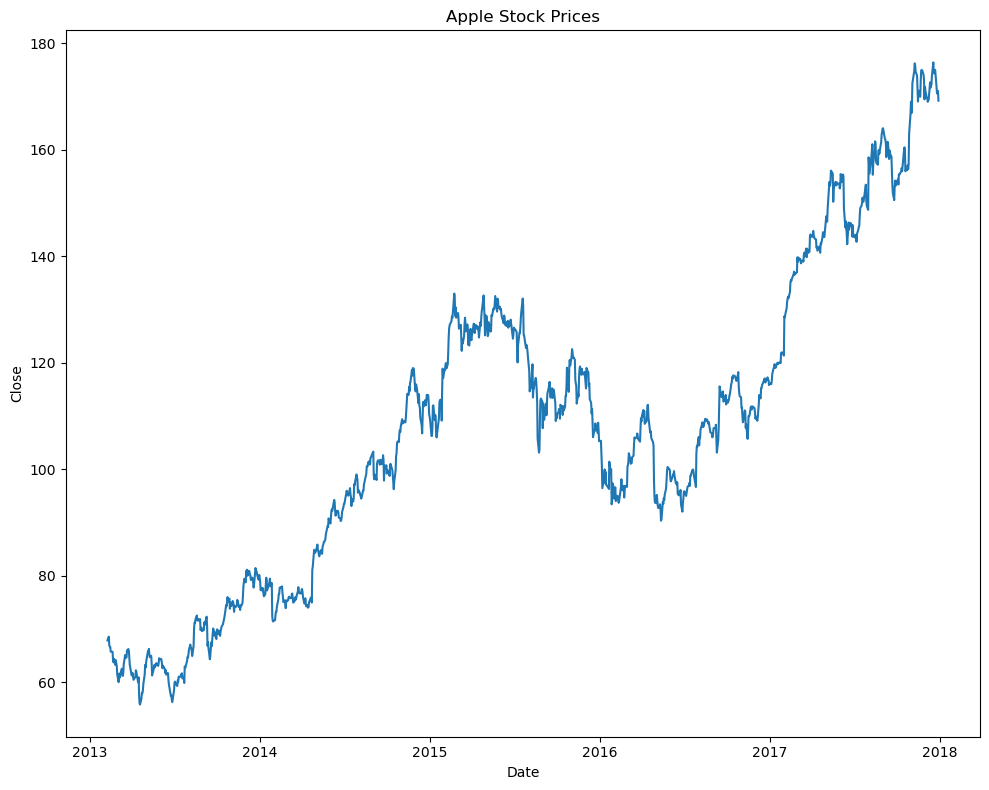

In [24]:
plt.figure(figsize=(10, 8))
plt.plot(prediction_range['date'], prediction_range['close'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Apple Stock Prices')
plt.tight_layout()

### Step 4: Preparing Data

In [25]:
close_data = apple.filter(['close'])

In [29]:
dataset = close_data.values

In [171]:
training_num = int(np.ceil(len(dataset) * .80))

In [172]:
training_num

1008

In [173]:
scaler = MinMaxScaler()

In [174]:
scaler_data = scaler.fit_transform(dataset)

In [175]:
train_data = scaler_data[:training_num, :]
test_data = scaler_data[training_num-60:, :]

In [176]:
X_train, y_train = list(), list()

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [177]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [178]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [181]:
X_test, y_test, y_real = list(), list(), list()

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])
    y_real.append(dataset[training_num+i-60, 0])

In [180]:
X_test = list()
y_test = dataset[training_num:, :]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

In [182]:
X_test, y_test = np.array(X_test), np.array(y_test)

In [183]:
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### Step 5: Feature Engineering

### Step 6: Model Development

In [49]:
class LSTMModel(tf.keras.Model):
    def __init__(self):
        super().__init__(name='LSTMModel')
        self.lstm_1 = layers.LSTM(units=64, return_sequences=True)
        self.lstm_2 = layers.LSTM(units=64)
        self.dense = layers.Dense(32)
        self.out = layers.Dense(1)
        self.dropout = layers.Dropout(0.5)

    def call(self, x, training=False):
        x = self.lstm_1(x)
        x = self.lstm_2(x)
        x = self.dense(x)
        x = self.dropout(x)
        x = self.out(x)
        return x

In [184]:
model = LSTMModel()

In [185]:
_ = model(tf.random.normal([1, 60, 1]))

In [186]:
model.summary()

Model: "LSTMModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (1, 60, 64)                 │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (1, 64)                     │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (1, 32)                     │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (1, 1)                      │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
)

In [188]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0232 - val_loss: 0.0218
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0076 - val_loss: 0.0014
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0062 - val_loss: 0.0012
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0054 - val_loss: 0.0015
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0047 - val_loss: 0.0017
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0048 - val_loss: 0.0021
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0049 - val_loss: 9.6349e-04
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0051 - val_loss: 0.0082


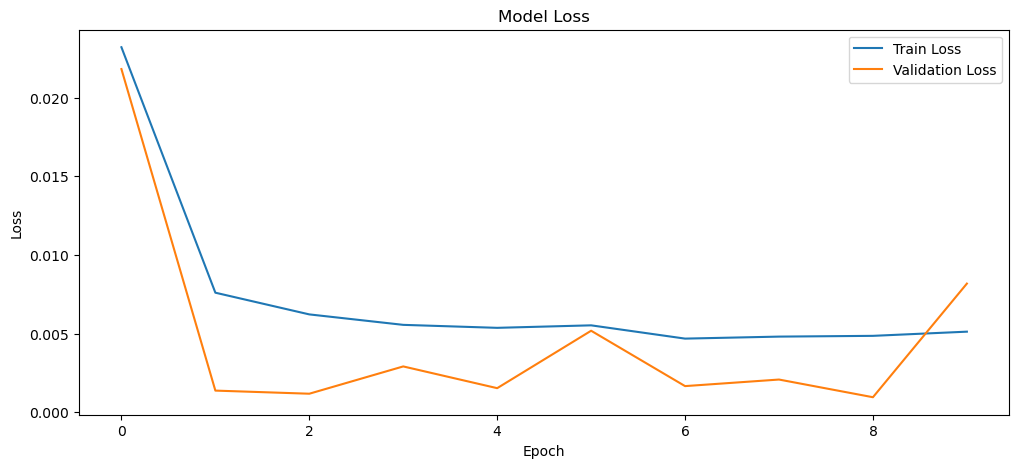

In [189]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

### Step 7: Model Evaluation

In [190]:
predictions = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [191]:
predictions = scaler.inverse_transform(predictions)

In [192]:
mse = np.mean(((predictions - y_real) ** 2))
rmse = np.sqrt(mse)

In [193]:
print("MSE", mse)
print("RMSE", np.sqrt(mse))

MSE 374.32270759427587
RMSE 19.34742121302671


In [194]:
train = apple[:training_num]
test = apple[training_num:]
test['Predictions'] = predictions

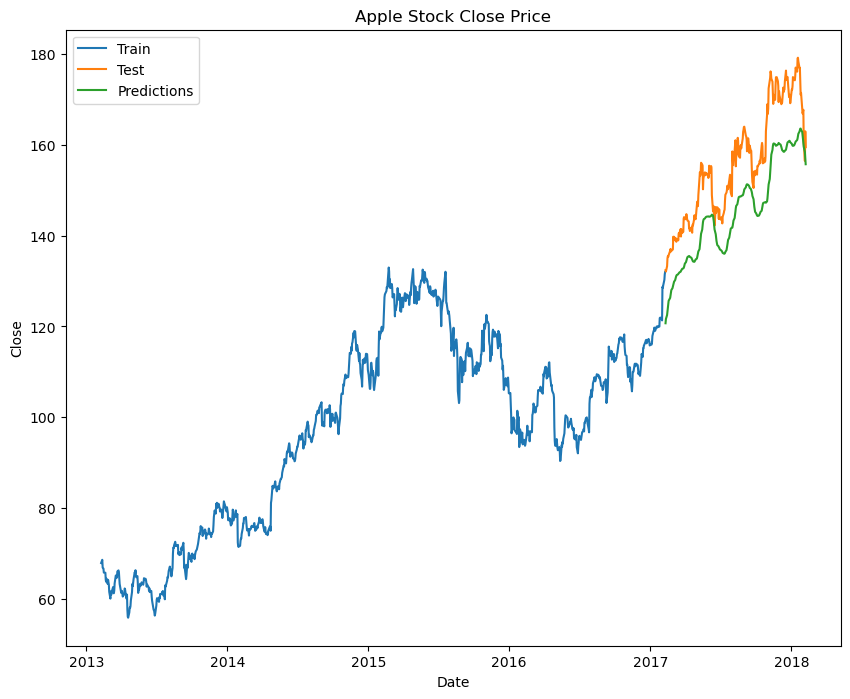

In [200]:
plt.figure(figsize=(10, 8))
plt.plot(train['date'], train['close'])
plt.plot(test['date'], test[['close', 'Predictions']])
plt.title('Apple Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])